# 10 · 연금복권 720+ 심층 분석 (Pension Deep-Dive)

> 부록 · *로또(비복원·종속)와 대비되는 연금복권(복원·독립)을 데이터로 파헤친다.*

노트북 02에서 로또와 연금복권의 **표본추출 구조 차이**(비복원·종속 vs 복원·독립)를 이론으로 다뤘습니다.
이 노트북은 연금복권 데이터를 직접 분석합니다: **조(1–5) + 6자리(0–9)** 구조, 균등성 검정, 그리고
720+의 **등수별 당첨 확률**.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.lotto_ds import viz, pension as pn

viz.apply_style()
df = pn.load_main()
print(f"연금복권 본추첨: {len(df):,}회 (draw {df.draw_no.min()}–{df.draw_no.max()})")

연금복권 본추첨: 322회 (draw 1–322)


## 1. 조 출현 균등성 (Group uniformity)
조는 1–5, 각 조가 균등하다면 기대 빈도는 `N/5`. 카이제곱으로 검정합니다.

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


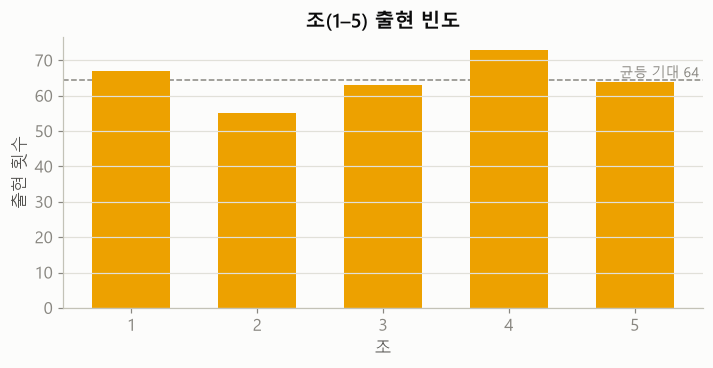

χ² = 2.66, df=4, p = 0.6165  →  균등과 구별 안 됨


In [2]:
gf = pn.group_frequency(df)
chi2, p = stats.chisquare(gf["count"].to_numpy(), np.full(5, gf["count"].sum() / 5))

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.bar(gf["group"], gf["count"], color=viz.CAT[2], width=0.62)
viz.reference_line(ax, gf["expected"].iloc[0], label=f"균등 기대 {gf['expected'].iloc[0]:.0f}")
ax.set_title("조(1–5) 출현 빈도")
ax.set_xlabel("조"); ax.set_ylabel("출현 횟수"); ax.set_xticks(gf["group"])
viz.savefig(fig, "10_group_freq.png"); plt.show()
print(f"χ² = {chi2:.2f}, df=4, p = {p:.4f}  →  {'균등과 구별 안 됨' if p>0.05 else '편향 발견'}")

## 2. 위치별 자릿수 균등성 (Per-position digit uniformity)
각 자리(0–9)가 균등·독립이어야 합니다. 6×10 히트맵 + 위치별 카이제곱.

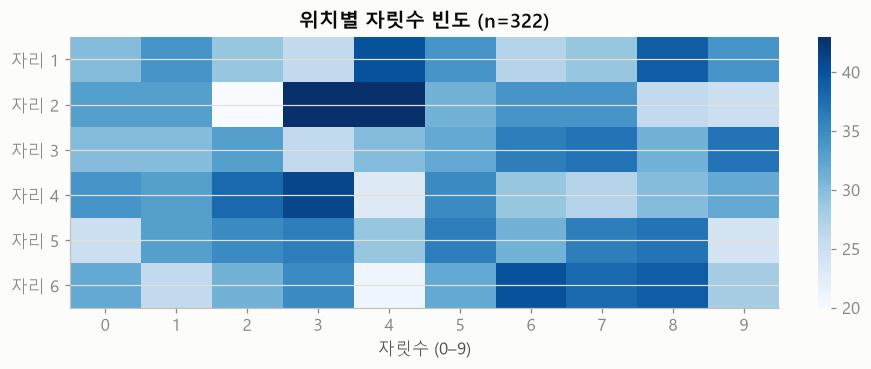

위치별 카이제곱 p: [np.float64(0.694), np.float64(0.092), np.float64(0.936), np.float64(0.559), np.float64(0.701), np.float64(0.327)]
→ 모든 위치 p > 0.05. 자릿수 위치 편향 없음 (균등·독립과 부합).


In [3]:
pos = pn.digit_position_frequency(df)
fig, ax = plt.subplots(figsize=(9, 3.2))
im = ax.imshow(pos, aspect="auto", cmap="Blues")
ax.set_yticks(range(6), [f"자리 {i+1}" for i in range(6)])
ax.set_xticks(range(10)); ax.set_xlabel("자릿수 (0–9)")
ax.set_title(f"위치별 자릿수 빈도 (n={len(df)})")
cb = fig.colorbar(im, ax=ax, fraction=0.025); cb.outline.set_visible(False)
viz.savefig(fig, "10_digit_heatmap.png"); plt.show()

pos_p = []
for i in range(6):
    _, pp = stats.chisquare(pos[i], np.full(10, pos[i].sum() / 10))
    pos_p.append(pp)
print("위치별 카이제곱 p:", [round(x, 3) for x in pos_p])
print("→ 모든 위치 p > 0.05. 자릿수 위치 편향 없음 (균등·독립과 부합).")

## 3. 자릿수 합계 분포 (Digit-sum distribution)
6자리는 **독립 복원** 추출이라, 합계는 CLT로 정규에 가깝고 이론 평균은 `6 × 4.5 = 27`입니다.
(로또의 합계 평균 138과 대비 — 구조가 다르면 통계도 다릅니다.)

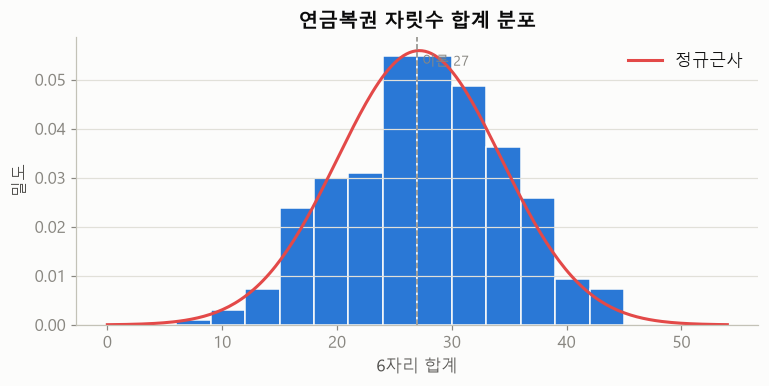

관측 평균 27.18 (이론 27) · 표준편차 7.13


In [4]:
sums = pn.digit_sum_series(df)
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(sums, bins=range(0, 56, 3), density=True, color=viz.CAT[0],
        edgecolor=viz.INK["surface"], linewidth=1.0)
xs = np.linspace(0, 54, 200)
ax.plot(xs, stats.norm.pdf(xs, sums.mean(), sums.std()), color=viz.CAT[5], lw=2, label="정규근사")
ax.axvline(27, ls="--", color=viz.INK["muted"], lw=1)
ax.text(27, ax.get_ylim()[1]*0.9, " 이론 27", fontsize=9, color=viz.INK["muted"])
ax.set_title("연금복권 자릿수 합계 분포"); ax.set_xlabel("6자리 합계"); ax.set_ylabel("밀도")
ax.legend(frameon=False)
viz.savefig(fig, "10_digit_sum.png"); plt.show()
print(f"관측 평균 {sums.mean():.2f} (이론 27) · 표준편차 {sums.std():.2f}")

## 4. 등수별 당첨 확률 (Prize-tier odds)
720+는 **뒤 몇 자리**가 맞느냐로 등수가 갈립니다 (1등은 조까지 일치).

tier      match            확률          prize
  1등    조 + 6자리 1 / 5,000,000 매월 700만원 × 20년
  2등 6자리 (조 무관) 1 / 1,000,000 매월 100만원 × 10년
  3등      뒤 5자리   1 / 100,000          100만원
  4등      뒤 4자리    1 / 10,000           10만원
  5등      뒤 3자리     1 / 1,000            5만원
  6등      뒤 2자리       1 / 100            5천원
  7등      뒤 1자리        1 / 10            1천원


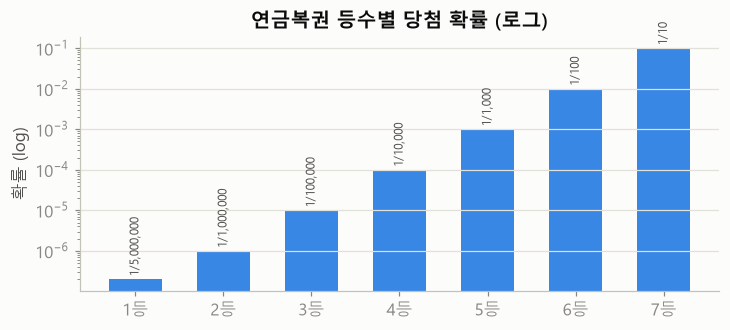

In [5]:
tiers = pd.DataFrame(pn.PRIZE_TIERS)
tiers["확률"] = tiers["one_in"].map(lambda n: f"1 / {n:,}")
print(tiers[["tier", "match", "확률", "prize"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(7.5, 3))
ax.bar(tiers["tier"], 1 / tiers["one_in"], color=viz.SEQ[3], width=0.6)
ax.set_yscale("log")
for t, o in zip(tiers["tier"], tiers["one_in"]):
    ax.text(t, 1/o, f" 1/{o:,}", ha="center", va="bottom", fontsize=8, color=viz.INK["secondary"], rotation=90)
ax.set_title("연금복권 등수별 당첨 확률 (로그)"); ax.set_ylabel("확률 (log)")
viz.savefig(fig, "10_prize_odds.png"); plt.show()

## 5. 로또 vs 연금 — 구조가 통계를 지배한다

| | 로또 6/45 | 연금복권 |
|---|---|---|
| 추출 | 비복원 (종속) | 복원 (독립) |
| 합계 평균 | 138 | 27 |
| 한 칸의 분포 | 정렬 위치별 비균등 | 각 자리 Uniform{0–9} |
| 1등 확률 | 1 / 8,145,060 | 1 / 5,000,000 |

**결론:** 연금복권 역시 조·자릿수 모두 균등하며, 예측 가능한 구조가 없습니다. 두 복권의 차이는
*당첨 규칙과 표본추출 구조*이지 "예측 가능성"이 아닙니다 — 둘 다 공정한 난수입니다.